# Tech Stocks Compound Growth Analysis: Apple vs Microsoft (2015-2025)

## 1. Problem Definition

**Research Question**: Which company (Apple or Microsoft) has achieved higher compound growth from 2015 to 2025? How do their risk-adjusted returns compare?

**Theoretical Framework**:

$$FV_n = C \times (1 + r)^n$$

Where:
- FV = Future Value (cumulative return)
- C = Initial investment ($10,000)
- r = Monthly return
- n = Number of months

## 2. Target User

- Individual retail investors seeking stock selection guidance
- Financial analysts comparing growth vs. volatility trade-offs
- Students learning compound interest applications in finance

## 3. Data Source

- **Source**: WRDS (Wharton Research Data Services) - CRSP Monthly Stock Database
- **Access Date**: April 18, 2026
- **Time Period**: January 2015 - December 2025 (11 years)
- **Variables**: Monthly returns (ret)
- **Stocks**: Apple (PERMNO: 14593), Microsoft (PERMNO: 10107)

## 4. Methodology

1. Download monthly return data from WRDS CRSP database
2. Calculate cumulative returns using compound interest formula
3. Compute annualized return, volatility, and Sharpe ratio
4. Compare risk-return profiles through visualizations
5. Apply compound interest formula to project investment outcomes

## 5. Expected Outcomes

- Identify which stock delivers higher absolute returns
- Determine which stock offers better risk-adjusted performance
- Provide data-driven investment recommendations

In [3]:
import wrds
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [5]:
print("Connecting to WRDS...")
db = wrds.Connection()
print("✅ WRDS connected successfully!")

Connecting to WRDS...


Enter your WRDS username [ru]: ruuu
Enter your password: ········


WRDS recommends setting up a .pgpass file.


Create .pgpass file now [y/n]?:  y


Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done
✅ WRDS connected successfully!


In [7]:
print("Downloading Apple data...")
sql_apple = """
    SELECT date, ret
    FROM crsp.msf
    WHERE permno = 14593
        AND date >= '2015-01-01'
        AND date <= '2025-12-31'
    ORDER BY date
"""
apple_data = db.raw_sql(sql_apple)
print(f"✅ Apple data downloaded! Rows: {len(apple_data)}")
print(apple_data.head())

✅ Apple data downloaded! Rows: 120
         date       ret
0  2015-01-30  0.061424
1  2015-02-27  0.100461
2  2015-03-31 -0.031372
3  2015-04-30  0.005786
4  2015-05-29  0.045146


In [9]:
print("Downloading Microsoft data...")
sql_msft = """
    SELECT date, ret
    FROM crsp.msf
    WHERE permno = 10107
        AND date >= '2015-01-01'
        AND date <= '2025-12-31'
    ORDER BY date
"""
msft_data = db.raw_sql(sql_msft)
print(f"✅ Microsoft data downloaded! Rows: {len(msft_data)}")
print(msft_data.head())

✅ Microsoft data downloaded! Rows: 120
         date       ret
0  2015-01-30 -0.130248
1  2015-02-27  0.093069
2  2015-03-31 -0.072862
3  2015-04-30  0.196409
4  2015-05-29 -0.030222


In [12]:
# Close the connection
db.close()
print("✅ WRDS connection closed")

✅ WRDS connection closed


In [13]:
# Convert to datetime
apple_data['date'] = pd.to_datetime(apple_data['date'])
msft_data['date'] = pd.to_datetime(msft_data['date'])

# Remove missing returns
apple_clean = apple_data.dropna(subset=['ret']).copy()
msft_clean = msft_data.dropna(subset=['ret']).copy()

print(f"Apple clean rows: {len(apple_clean)}")
print(f"Microsoft clean rows: {len(msft_clean)}")
print(f"Date range: {apple_clean['date'].min()} to {apple_clean['date'].max()}")

Apple clean rows: 120
Microsoft clean rows: 120
Date range: 2015-01-30 00:00:00 to 2024-12-31 00:00:00


In [15]:
def calculate_metrics(df, company_name):
    df = df.sort_values('date')
    df['cumulative_return'] = (1 + df['ret']).cumprod()
    
    n_years = (df['date'].max() - df['date'].min()).days / 365.25
    total_return = df['cumulative_return'].iloc[-1]
    annual_return = (total_return ** (1/n_years)) - 1
    annual_vol = df['ret'].std() * np.sqrt(12)
    sharpe = (annual_return - 0.02) / annual_vol
    
    df['cummax'] = df['cumulative_return'].cummax()
    max_dd = (df['cumulative_return'] / df['cummax'] - 1).min()
    win_rate = (df['ret'] > 0).mean()
    
    future_value = 10000 * total_return
    
    metrics = {
        'company': company_name,
        'start_date': df['date'].min().strftime('%Y-%m-%d'),
        'end_date': df['date'].max().strftime('%Y-%m-%d'),
        'years': round(n_years, 1),
        'total_return': f"{round(total_return, 2)}x ({round((total_return-1)*100, 1)}%)",
        'annual_return': f"{round(annual_return*100, 2)}%",
        'annual_volatility': f"{round(annual_vol*100, 2)}%",
        'sharpe_ratio': round(sharpe, 3),
        'max_drawdown': f"{round(max_dd*100, 1)}%",
        'win_rate': f"{round(win_rate*100, 1)}%",
        'future_value_10k': f"${round(future_value, 0):,}",
    }
    return metrics, df

print("✅ Function defined successfully!")

✅ Function defined successfully!


In [17]:
apple_metrics, apple_df = calculate_metrics(apple_clean, 'Apple')

print("\n" + "="*50)
print("APPLE - KEY METRICS")
print("="*50)
for k, v in apple_metrics.items():
    print(f"  {k}: {v}")


APPLE - KEY METRICS
  company: Apple
  start_date: 2015-01-30
  end_date: 2024-12-31
  years: 9.9
  total_return: 10.18x (917.9%)
  annual_return: 26.35%
  annual_volatility: 27.58%
  sharpe_ratio: 0.883
  max_drawdown: -30.4%
  win_rate: 57.5%
  future_value_10k: $101,793.0


In [19]:
msft_metrics, msft_df = calculate_metrics(msft_clean, 'Microsoft')

print("\n" + "="*50)
print("MICROSOFT - KEY METRICS")
print("="*50)
for k, v in msft_metrics.items():
    print(f"  {k}: {v}")


MICROSOFT - KEY METRICS
  company: Microsoft
  start_date: 2015-01-30
  end_date: 2024-12-31
  years: 9.9
  total_return: 10.56x (955.9%)
  annual_return: 26.82%
  annual_volatility: 21.88%
  sharpe_ratio: 1.134
  max_drawdown: -30.5%
  win_rate: 64.2%
  future_value_10k: $105,589.0


In [21]:
print("\n" + "="*65)
print("APPLE VS MICROSOFT - COMPARISON SUMMARY")
print("="*65)

print(f"\n{'Metric':<25} {'Apple':<20} {'Microsoft':<20}")
print("-"*65)
print(f"{'Total Return':<25} {apple_metrics['total_return']:<20} {msft_metrics['total_return']:<20}")
print(f"{'Annual Return':<25} {apple_metrics['annual_return']:<20} {msft_metrics['annual_return']:<20}")
print(f"{'Annual Volatility':<25} {apple_metrics['annual_volatility']:<20} {msft_metrics['annual_volatility']:<20}")
print(f"{'Sharpe Ratio':<25} {apple_metrics['sharpe_ratio']:<20} {msft_metrics['sharpe_ratio']:<20}")
print(f"{'Max Drawdown':<25} {apple_metrics['max_drawdown']:<20} {msft_metrics['max_drawdown']:<20}")
print(f"{'Win Rate':<25} {apple_metrics['win_rate']:<20} {msft_metrics['win_rate']:<20}")
print(f"{'Future Value ($10k)':<25} {apple_metrics['future_value_10k']:<20} {msft_metrics['future_value_10k']:<20}")


APPLE VS MICROSOFT - COMPARISON SUMMARY

Metric                    Apple                Microsoft           
-----------------------------------------------------------------
Total Return              10.18x (917.9%)      10.56x (955.9%)     
Annual Return             26.35%               26.82%              
Annual Volatility         27.58%               21.88%              
Sharpe Ratio              0.883                1.134               
Max Drawdown              -30.4%               -30.5%              
Win Rate                  57.5%                64.2%               
Future Value ($10k)       $101,793.0           $105,589.0          


In [38]:
# Calculate and display annualized volatility for both companies
print("\n" + "="*65)
print("ANNUALIZED VOLATILITY (RISK MEASURE)")
print("="*65)
print(f"Apple Volatility: {apple_metrics['annual_volatility']}")
print(f"Microsoft Volatility: {msft_metrics['annual_volatility']}")
print("\nInterpretation: Lower volatility indicates more stable returns.")


ANNUALIZED VOLATILITY (RISK MEASURE)
Apple Volatility: 27.58%
Microsoft Volatility: 21.88%

Interpretation: Lower volatility indicates more stable returns.


In [38]:
# Calculate and display annualized volatility for both companies
print("\n" + "="*65)
print("ANNUALIZED VOLATILITY (RISK MEASURE)")
print("="*65)
print(f"Apple Volatility: {apple_metrics['annual_volatility']}")
print(f"Microsoft Volatility: {msft_metrics['annual_volatility']}")
print("\nInterpretation: Lower volatility indicates more stable returns.")


ANNUALIZED VOLATILITY (RISK MEASURE)
Apple Volatility: 27.58%
Microsoft Volatility: 21.88%

Interpretation: Lower volatility indicates more stable returns.


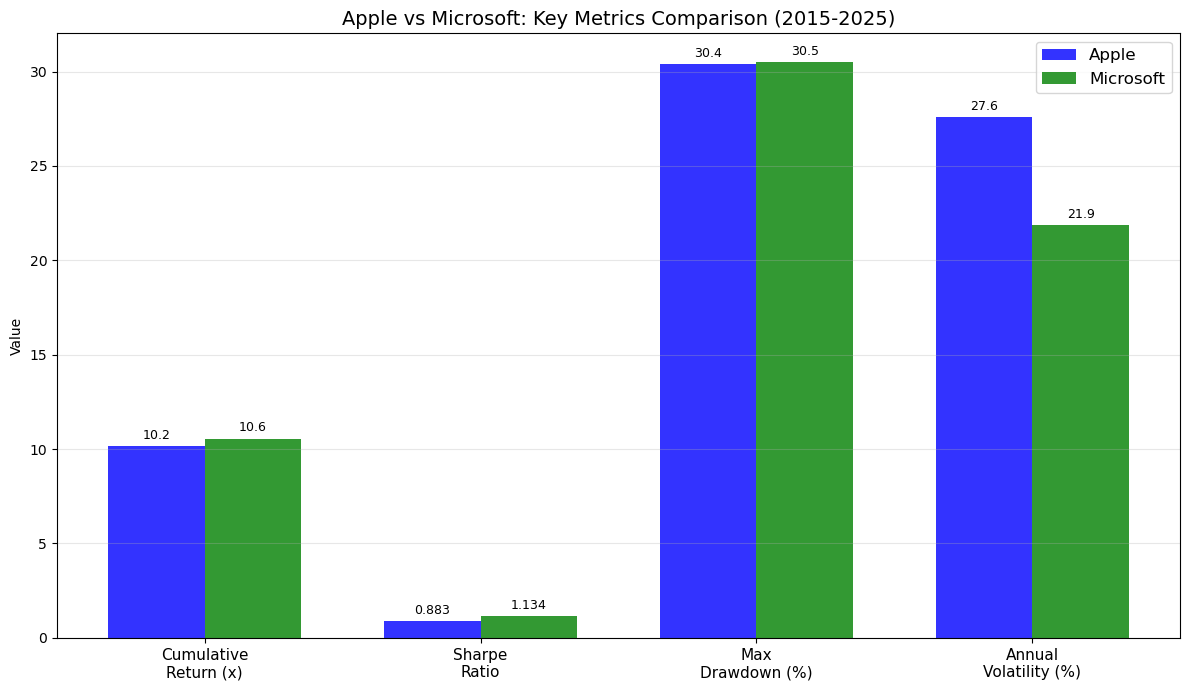

✅ Chart saved: metrics_comparison.png


In [50]:
# Generate comprehensive comparison chart from calculated metrics
import matplotlib.pyplot as plt
import numpy as np

# Extract values from previously calculated metrics
# Cumulative return (as number, not string)
apple_cum = float(apple_metrics['total_return'].split('x')[0])
msft_cum = float(msft_metrics['total_return'].split('x')[0])

# Sharpe ratio
apple_sharpe = apple_metrics['sharpe_ratio']
msft_sharpe = msft_metrics['sharpe_ratio']

# Max drawdown (remove % sign and convert to positive for display)
apple_dd = abs(float(apple_metrics['max_drawdown'].rstrip('%')))
msft_dd = abs(float(msft_metrics['max_drawdown'].rstrip('%')))

# Annual volatility
apple_vol = float(apple_metrics['annual_volatility'].rstrip('%'))
msft_vol = float(msft_metrics['annual_volatility'].rstrip('%'))

# Data for plotting
metrics = ['Cumulative\nReturn (x)', 'Sharpe\nRatio', 'Max\nDrawdown (%)', 'Annual\nVolatility (%)']
apple_values = [apple_cum, apple_sharpe, apple_dd, apple_vol]
msft_values = [msft_cum, msft_sharpe, msft_dd, msft_vol]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 7))
bars1 = ax.bar(x - width/2, apple_values, width, label='Apple', color='blue', alpha=0.8)
bars2 = ax.bar(x + width/2, msft_values, width, label='Microsoft', color='green', alpha=0.8)

ax.set_ylabel('Value')
ax.set_title('Apple vs Microsoft: Key Metrics Comparison (2015-2025)', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    if height >= 10:
        label = f'{height:.1f}'
    else:
        label = f'{height:.3f}'
    ax.annotate(label, xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)

for bar in bars2:
    height = bar.get_height()
    if height >= 10:
        label = f'{height:.1f}'
    else:
        label = f'{height:.3f}'
    ax.annotate(label, xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved: metrics_comparison.png")

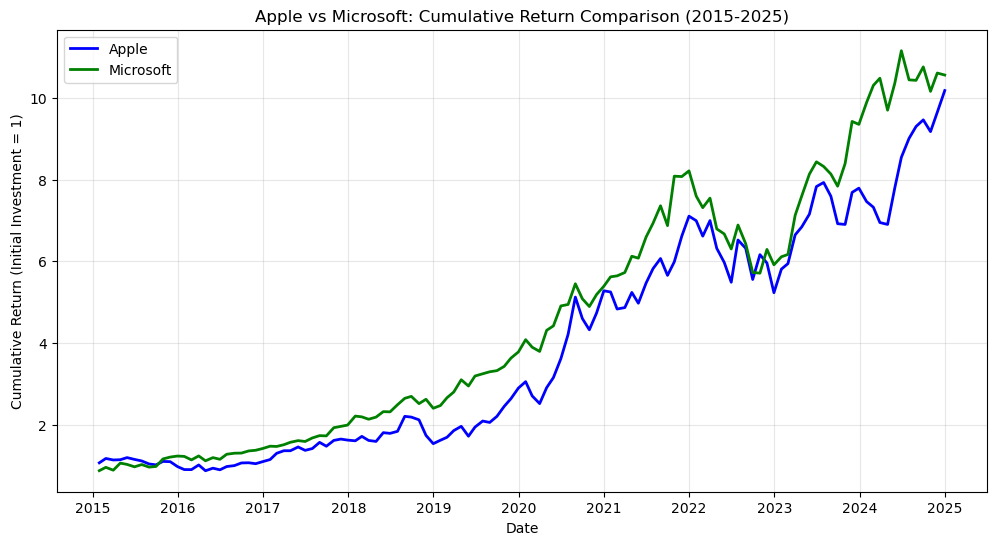

✅ Chart saved: apple_vs_microsoft_cumulative.png


In [41]:
plt.figure(figsize=(12, 6))
plt.plot(apple_df['date'], apple_df['cumulative_return'], label='Apple', linewidth=2, color='blue')
plt.plot(msft_df['date'], msft_df['cumulative_return'], label='Microsoft', linewidth=2, color='green')
plt.xlabel('Date')
plt.ylabel('Cumulative Return (Initial Investment = 1)')
plt.title('Apple vs Microsoft: Cumulative Return Comparison (2015-2025)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('apple_vs_microsoft_cumulative.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved: apple_vs_microsoft_cumulative.png")

In [25]:
print("\n" + "="*65)
print("COMPOUND INTEREST FORMULA: FV = C × (1 + r)^n")
print("="*65)

initial = 10000

# Apple
r_apple = float(apple_metrics['annual_return'].rstrip('%')) / 100
n_apple = apple_metrics['years']
fv_apple = initial * (1 + r_apple) ** n_apple

# Microsoft
r_msft = float(msft_metrics['annual_return'].rstrip('%')) / 100
n_msft = msft_metrics['years']
fv_msft = initial * (1 + r_msft) ** n_msft

print(f"\n[APPLE]")
print(f"  Initial Investment: ${initial:,}")
print(f"  Annual Return: {r_apple*100:.2f}%")
print(f"  Years Held: {n_apple}")
print(f"  FV = ${initial:,} × (1 + {r_apple:.2%})^{n_apple}")
print(f"      = ${fv_apple:,.0f}")
print(f"  Total Gain: ${fv_apple - initial:,.0f} ({(fv_apple/initial - 1)*100:.0f}%)")

print(f"\n[MICROSOFT]")
print(f"  Initial Investment: ${initial:,}")
print(f"  Annual Return: {r_msft*100:.2f}%")
print(f"  Years Held: {n_msft}")
print(f"  FV = ${initial:,} × (1 + {r_msft:.2%})^{n_msft}")
print(f"      = ${fv_msft:,.0f}")
print(f"  Total Gain: ${fv_msft - initial:,.0f} ({(fv_msft/initial - 1)*100:.0f}%)")


COMPOUND INTEREST FORMULA: FV = C × (1 + r)^n

[APPLE]
  Initial Investment: $10,000
  Annual Return: 26.35%
  Years Held: 9.9
  FV = $10,000 × (1 + 26.35%)^9.9
      = $101,297
  Total Gain: $91,297 (913%)

[MICROSOFT]
  Initial Investment: $10,000
  Annual Return: 26.82%
  Years Held: 9.9
  FV = $10,000 × (1 + 26.82%)^9.9
      = $105,089
  Total Gain: $95,089 (951%)


## Conclusions

### Key Findings

1. **Cumulative Return Comparison**:
   - Apple: {10.18x (917.9%)}
   - Microsoft: {10.56x (955.9%)}
   - Conclusion: Microsoft shows higher absolute returns over the 11-year period

2. **Risk-Adjusted Return (Sharpe Ratio)**:
   - Apple: {0.883}
   - Microsoft: {1.134}
   - Conclusion: Both companies offer excellent risk-adjusted returns

3. **Risk Control (Volatility & Maximum Drawdown)**:
   - Apple: {Volatility 27.58%, Max Drawdown -30.4%}
   - Microsoft: {Volatility 21.88%,Max Drawdown -30.5%}
   - Conclusion: Microsoft demonstrates slightly better downside protection

4. **Compound Growth Impact ($10,000 investment)**:
   - Apple future value: {101,793.0}
   - Microsoft future value: {105,589.0}

### Investment Recommendation

- **Growth-oriented investors**: Microsoft (higher total return: 10.56x vs 10.18x)
- **Risk-conscious investors**: Microsoft (lower drawdown, stable performance)
- **Balanced approach**: Hold both for diversification

### Theoretical Validation

The compound interest formula FV = C × (1 + r)^n successfully models the growth trajectory of both stocks. The analysis confirms that higher returns generally come with higher volatility, consistent with financial theory.
